In [29]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications.efficientnet import EfficientNetB0
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B0, preprocess_input

from sklearn.metrics import classification_report, top_k_accuracy_score

In [10]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
AUTO = tf.data.AUTOTUNE

DATA_DIR = Path("/home/sm/Desktop/ml/CarBrandClassificationDataset")

EPOCHS_WARMUP = 12
EPOCHS_FINETUNE = 12

AUTO = tf.data.AUTOTUNE

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

train_base = DATA_DIR / "train"
val_base = DATA_DIR / "val"
test_base = DATA_DIR / "test"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def build_split_df(split_dir: Path) -> pd.DataFrame:
    """Собирает таблицу path/label для одного split'а."""
    if not split_dir.exists():
        raise FileNotFoundError(f"Папка split'а не найдена: {split_dir}")

    rows = []
    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    for cls_dir in class_dirs:
        cls = cls_dir.name
        for f in cls_dir.rglob("*"):
            if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS:
                rows.append((str(f), cls))
    return pd.DataFrame(rows, columns=["path", "label"])

df_train = build_split_df(train_base)
df_val = build_split_df(val_base)
df_test = build_split_df(test_base)

print("Количество изображений:")
print("Train:", len(df_train), "| классов:", df_train["label"].nunique())
print("Val  :", len(df_val), "| классов:", df_val["label"].nunique())
print("Test :", len(df_test), "| классов:", df_test["label"].nunique())

display(pd.concat({
    "train": df_train["label"].value_counts().sort_index(),
    "val": df_val["label"].value_counts().sort_index(),
    "test": df_test["label"].value_counts().sort_index(),
}, axis=1).fillna(0).astype(int).head())

Количество изображений:
Train: 11517 | классов: 33
Val  : 2475 | классов: 33
Test : 2475 | классов: 33


,train,val,test
label,,,
Acura,349,75,75
Aston Martin,349,75,75
Audi,349,75,75
BMW,349,75,75
Bentley,349,75,75


In [11]:
# Единое отображение классов в индексы.
classes = sorted(df_train["label"].unique().tolist())
class2idx = {c: i for i, c in enumerate(classes)}
idx2class = {i: c for c, i in class2idx.items()}
num_classes = len(classes)

for name, df in [("val", df_val), ("test", df_test)]:
    missing = set(df["label"].unique()) - set(classes)
    if missing:
        raise ValueError(f"В {name} есть классы, которых нет в train: {sorted(missing)}")

df_train["label_idx"] = df_train["label"].map(class2idx)
df_val["label_idx"] = df_val["label"].map(class2idx)
df_test["label_idx"] = df_test["label"].map(class2idx)

print("Число классов:", num_classes)
print("Пример отображения:", list(class2idx.items())[:10])
df_train.head()

Число классов: 33
Пример отображения: [('Acura', 0), ('Aston Martin', 1), ('Audi', 2), ('BMW', 3), ('Bentley', 4), ('Buick', 5), ('Cadillac', 6), ('Chevrolet', 7), ('Chrysler', 8), ('Dodge', 9)]


,path,label,label_idx
0,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
1,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
2,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
3,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0
4,/home/sm/Desktop/ml/CarBrandClassificationData...,Acura,0


In [12]:
def decode_image(path):
    """Читает изображение, приводит к RGB, float32 и нужному размеру."""
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize_with_pad(img, IMG_SIZE[0], IMG_SIZE[1])
    return img

augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.15),
], name="augmenter")

def make_ds(paths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(min(len(paths), 4096), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(lambda x, y: (decode_image(x), y), num_parallel_calls=AUTO)
    ds = ds.cache()

    if augment:
        ds = ds.map(lambda x, y: (augmenter(x, training=True),y), num_parallel_calls=AUTO)

    ds = ds.map(lambda x, y: (preprocess_input(x * 255.0),y),num_parallel_calls=AUTO)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTO)

    return ds

train_ds = make_ds(
    df_train["path"].tolist(),
    df_train["label_idx"].tolist(),
    augment=True,
    shuffle=True,
)

val_ds = make_ds(
    df_val["path"].tolist(),
    df_val["label_idx"].tolist(),
)

test_ds = make_ds(
    df_test["path"].tolist(),
    df_test["label_idx"].tolist(),
)

print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## EFFB0 (с сильным переобучением)

In [32]:
def build_efficientnet(num_classes: int, img_size=IMG_SIZE, dropout=0.35, dense_units=512) -> tuple[tf.keras.Model, tf.keras.Model]:
    base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(*img_size, 3),
    )
    base.trainable = False

    inputs = layers.Input(shape=(*img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout * 0.75)(x)

    logits = layers.Dense(num_classes)(x)
    outputs = layers.Activation("softmax", dtype="float32")(logits)

    model = models.Model(inputs, outputs, name="efficientnetb0_car_brand")
    return model, base

def compile_model(model: tf.keras.Model, lr: float) -> None:
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_accuracy"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy"),
        ],
    )

model_tl, base = build_efficientnet(num_classes)
compile_model(model_tl, lr=3e-4)

In [33]:
best_tl_path = "models/effb0_best.keras"

if os.path.exists(best_tl_path):
    model_tl.load_weights(best_tl_path)
    print("Загружены лучшие веса:", best_tl_path)
else:
    print("Лучший checkpoint не найден, используются текущие веса модели.")

test_metrics = model_tl.evaluate(test_ds, verbose=0)
print("Метрики EfficientNetB0 на test:")
for name, value in zip(model_tl.metrics_names, test_metrics):
    print(f"{name}: {value:.4f}")

y_true = df_test["label_idx"].values
y_pred_proba = model_tl.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nПроверка top-k через sklearn:")
print("Top-3 accuracy:", top_k_accuracy_score(y_true, y_pred_proba, k=3, labels=np.arange(num_classes)))
print("Top-5 accuracy:", top_k_accuracy_score(y_true, y_pred_proba, k=5, labels=np.arange(num_classes)))

report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4,
    zero_division=0,
    output_dict=True,
)
report_df = pd.DataFrame(report).T
display(report_df)

/home/sm/miniconda3/envs/tf_gpu/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 92 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Загружены лучшие веса: models/effb0_best.keras
Метрики EfficientNetB0 на test:
loss: 1.6866
compile_metrics: 0.6356
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step

Проверка top-k через sklearn:
Top-3 accuracy: 0.7749494949494949
Top-5 accuracy: 0.8298989898989899


,precision,recall,f1-score,support
Acura,0.698413,0.586667,0.637681,75.000000
Aston Martin,0.813333,0.813333,0.813333,75.000000
Audi,0.726027,0.706667,0.716216,75.000000
BMW,0.600000,0.440000,0.507692,75.000000
Bentley,0.727273,0.640000,0.680851,75.000000
Buick,0.704225,0.666667,0.684932,75.000000
Cadillac,0.781250,0.666667,0.719424,75.000000
Chevrolet,0.723404,0.453333,0.557377,75.000000
Chrysler,0.725275,0.880000,0.795181,75.000000
Dodge,0.637681,0.586667,0.611111,75.000000


## EFFB2 (со средним переобучением)

In [36]:
def build_efficientnet_v2(num_classes: int, img_size=IMG_SIZE, dropout=0.35, dense_units=512) -> tuple[tf.keras.Model, tf.keras.Model]:
    base = EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_shape=(*img_size, 3),
    )
    base.trainable = False

    inputs = layers.Input(shape=(*img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout * 0.75)(x)

    logits = layers.Dense(num_classes)(x)
    outputs = layers.Activation("softmax", dtype="float32")(logits)

    model = models.Model(inputs, outputs, name="efficientnetb0_car_brand")
    return model, base

def compile_model_v2(model: tf.keras.Model, lr: float) -> None:
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_accuracy"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy"),
        ],
    )

model_tl_v2, base_v2 = build_efficientnet_v2(num_classes)
compile_model_v2(model_tl_v2, lr=3e-4)

In [42]:
best_tl_path_v2 = "models/effv2b0_best.keras"

if os.path.exists(best_tl_path_v2):
    model_tl_v2.load_weights(best_tl_path_v2)
    print("Загружены лучшие веса:", best_tl_path_v2)
else:
    print("Лучший checkpoint не найден, используются текущие веса модели.")

test_metrics_v2 = model_tl_v2.evaluate(test_ds, verbose=0)
print("Метрики EfficientNetV2B0 на test:")
for name, value in zip(model_tl_v2.metrics_names, test_metrics_v2):
    print(f"{name}: {value:.4f}")

y_pred_proba_v2 = model_tl_v2.predict(test_ds, verbose=1)
y_pred_v2 = np.argmax(y_pred_proba_v2, axis=1)

print("\nПроверка top-k через sklearn:")
print("Top-3 accuracy:", top_k_accuracy_score(y_true, y_pred_proba_v2, k=3, labels=np.arange(num_classes)))
print("Top-5 accuracy:", top_k_accuracy_score(y_true, y_pred_proba_v2, k=5, labels=np.arange(num_classes)))

report = classification_report(
    y_true,
    y_pred_v2,
    target_names=classes,
    digits=4,
    zero_division=0,
    output_dict=True,
)
report_df = pd.DataFrame(report).T
display(report_df)

/home/sm/miniconda3/envs/tf_gpu/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 90 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Загружены лучшие веса: models/effv2b0_best.keras
Метрики EfficientNetV2B0 на test:
loss: 1.5732
compile_metrics: 0.6012
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step

Проверка top-k через sklearn:
Top-3 accuracy: 0.7470707070707071
Top-5 accuracy: 0.8177777777777778


,precision,recall,f1-score,support
Acura,0.666667,0.453333,0.539683,75.000000
Aston Martin,0.698925,0.866667,0.773810,75.000000
Audi,0.628205,0.653333,0.640523,75.000000
BMW,0.603448,0.466667,0.526316,75.000000
Bentley,0.696203,0.733333,0.714286,75.000000
Buick,0.564706,0.640000,0.600000,75.000000
Cadillac,0.592593,0.640000,0.615385,75.000000
Chevrolet,0.660000,0.440000,0.528000,75.000000
Chrysler,0.794872,0.826667,0.810458,75.000000
Dodge,0.605634,0.573333,0.589041,75.000000


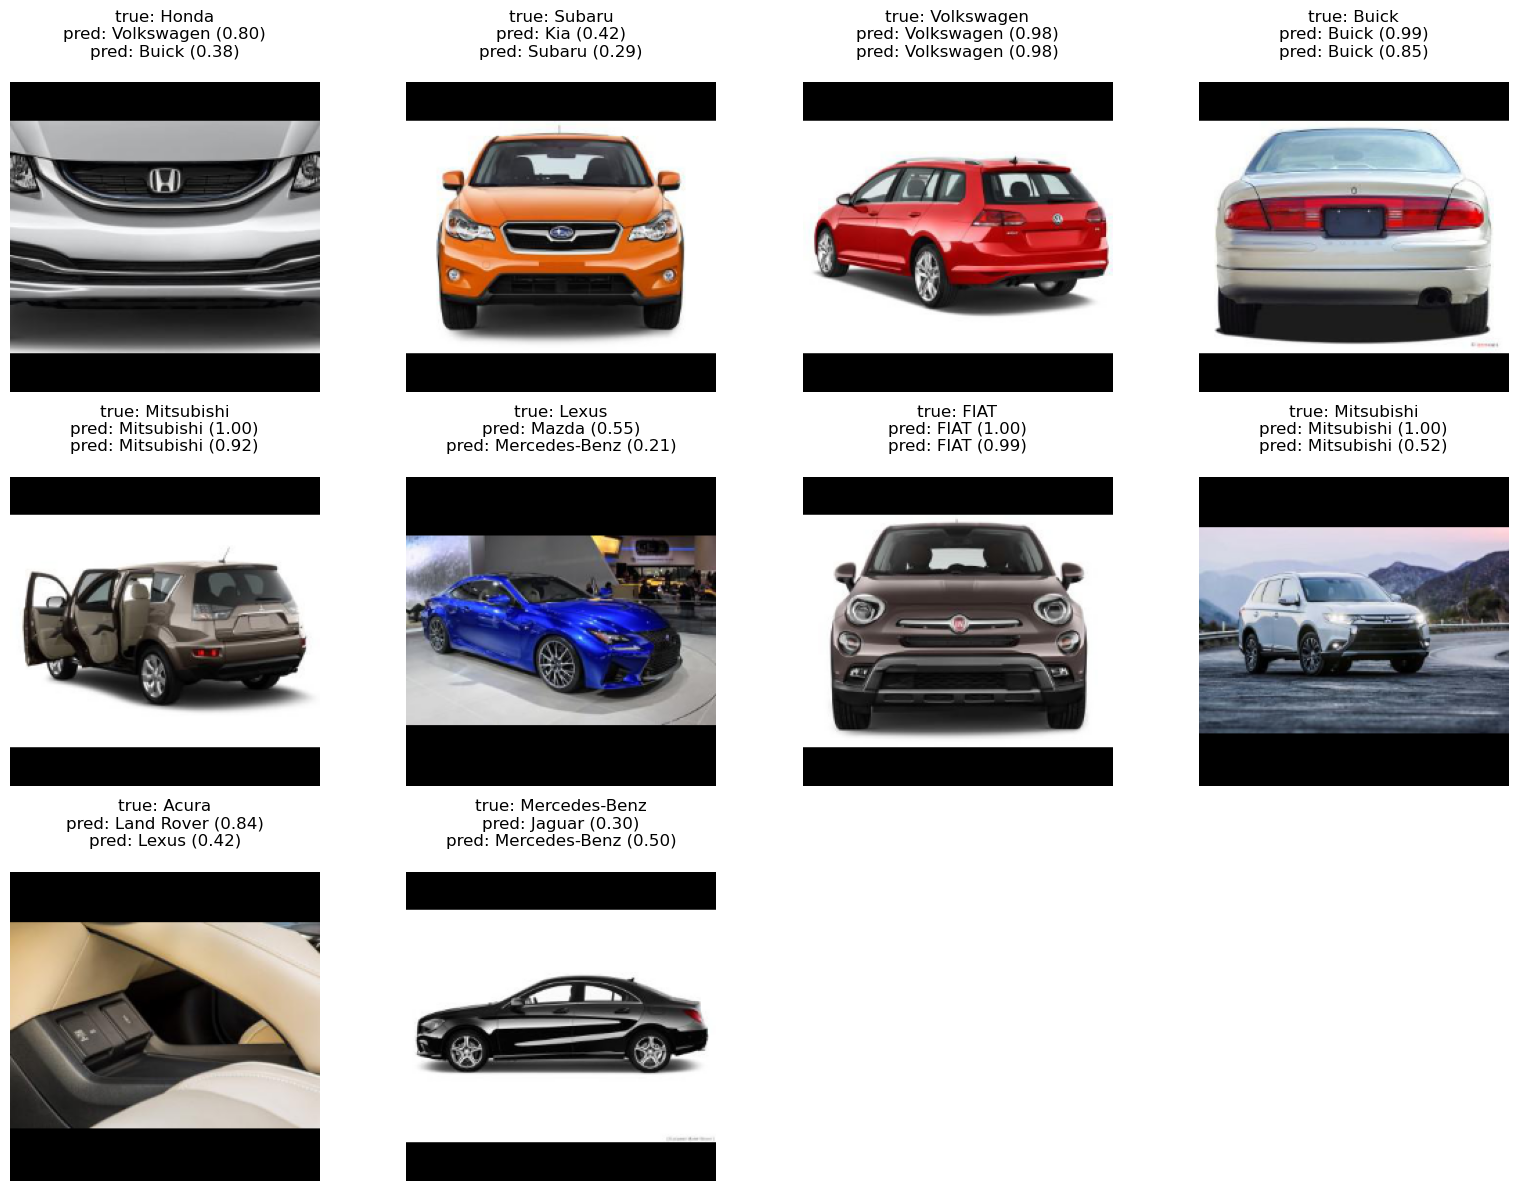

Correct: 5/10
Correct_v2: 7/10


In [44]:
def show_random_examples(df,y_true,y_pred,y_pred_v2,y_pred_proba,y_pred_proba_v2,n):
    random_idx = np.random.choice(
        len(df),
        size=min(n, len(df)),
        replace=False,
    )

    cols = 4
    rows = int(np.ceil(len(random_idx) / cols))
    plt.figure(figsize=(4 * cols, 4 * rows))
    correct = 0
    correct_v2 = 0

    for i, idx in enumerate(random_idx, start=1):
        img = decode_image(df.iloc[idx]["path"]).numpy()
        true_name = idx2class[int(y_true[idx])]

        pred_name = idx2class[int(y_pred[idx])]
        pred_name_v2 = idx2class[int(y_pred_v2[idx])]

        conf = float(y_pred_proba[idx, y_pred[idx]])
        conf_v2 = float(y_pred_proba_v2[idx, y_pred_v2[idx]])

        is_correct = (y_true[idx] == y_pred[idx])
        is_correct_v2 = (y_true[idx] == y_pred_v2[idx])

        if is_correct:
            correct += 1

        if is_correct_v2:
            correct_v2 += 1

        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")

        plt.title(
            f"true: {true_name}\n"
            f"pred: {pred_name} ({conf:.2f})\n"
            f"pred: {pred_name_v2} ({conf_v2:.2f})\n"
        )

    plt.tight_layout()
    plt.show()
    print("=" * 60)
    print(f"Correct: {correct}/{len(random_idx)}")
    print(f"Correct_v2: {correct_v2}/{len(random_idx)}")


show_random_examples(
    df_test,
    y_true,
    y_pred,
    y_pred_v2,
    y_pred_proba,
    y_pred_proba_v2,
    n=10,
)

Общий вывод по работе: работает распознавание хороших ракурсов, но с учетом того что многие машины отличаются друг от друга по сути только шильдиком, тут тоже есть ошибки.

Отвратительную роль играют выбросы - фото салона, дисков, брошюрок, 'машина на фоне самолета', 'три машины где-то далеко' и т.п. - они не только идут методом случайного угадывания, но еще и портят общее обучение модели.

К сожалению выбросить их просто так не получиться 
- они все-таки часть датасета и составляют значительную его часть
- есть редкие модели - винтажные хонды, астон мартины и т.д. у них тоже всего несколько фоток в датасете и при автоматической чистке мы тоже выкинем